# Same-Day Model Comparison

Compare LSTM, Transformer, and Transformer-LSTM hybrid predictions on identical January 2025 forecast samples.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn

DATA_PATH = Path("online_data/air_qual/air_qual.csv")
WEATHER_PATH = Path("processed_data_pkl/weather_global_2014_2025.pkl")
MODEL_DIR = Path("models_saved")
MODEL_PATHS = {
    "Transformer-LSTM 4.4": MODEL_DIR / "4.4transformer_lstm.pkl",
    "Transformer-LSTM 4.5 CPU": MODEL_DIR / "4.5transformer_lstm_optimized_cpu.pkl",
    "Multivariate 4.6": MODEL_DIR / "4.6multivariate.pkl",
}
TARGET_COL = "pm2_5 (μg/m³)"
FEATURE_COLS = [TARGET_COL, "hour_sin", "hour_cos"]
MULTIVARIATE_COLS = [
    TARGET_COL,
    "hour_sin",
    "hour_cos",
    "temperature_2m (°C)",
    "surface_pressure (hPa)",
    "wind_speed_100m (km/h)",
    "precipitation (mm)",
]
INPUT_WINDOW = 24 * 3
OUTPUT_WINDOW = 24
TEST_START = pd.Timestamp("2025-01-01 00:00:00")
TEST_END = pd.Timestamp("2025-01-31 23:00:00")
sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
DEVICE = torch.device("cpu")


def add_time_features(frame, timestamp_col):
    frame = frame.copy()
    frame[timestamp_col] = pd.to_datetime(frame[timestamp_col], errors="coerce")
    frame["hour_sin"] = np.sin(2 * np.pi * frame[timestamp_col].dt.hour / 24.0)
    frame["hour_cos"] = np.cos(2 * np.pi * frame[timestamp_col].dt.hour / 24.0)
    return frame


def make_sequences(frame, feature_cols):
    values = frame[feature_cols].to_numpy()
    targets = frame[TARGET_COL].to_numpy()
    inputs, outputs = [], []
    for start in range(len(frame) - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        inputs.append(values[start:start + INPUT_WINDOW])
        outputs.append(targets[start + INPUT_WINDOW:start + INPUT_WINDOW + OUTPUT_WINDOW])
    return np.asarray(inputs), np.asarray(outputs)


air = pd.read_csv(DATA_PATH)
air[TARGET_COL] = pd.to_numeric(air[TARGET_COL], errors="coerce")
air = add_time_features(air, "time")
air = air.dropna(subset=["time", TARGET_COL]).drop_duplicates("time")
df_univariate = air.set_index("time")[FEATURE_COLS].sort_index().asfreq("h")

with WEATHER_PATH.open("rb") as file:
    weather = pickle.load(file)
weather = add_time_features(weather, "timestamp")
weather = weather[["timestamp"] + [
    "temperature_2m (°C)",
    "surface_pressure (hPa)",
    "wind_speed_100m (km/h)",
    "precipitation (mm)",
]].copy()
weather = weather.dropna(subset=["timestamp"]).drop_duplicates("timestamp")

multivariate_source = air[["time", TARGET_COL, "hour_sin", "hour_cos"]].merge(
    weather,
    left_on="time",
    right_on="timestamp",
    how="inner",
)
df_multivariate = (
    multivariate_source.set_index("time")[MULTIVARIATE_COLS]
    .sort_index()
    .asfreq("h")
)

if df_univariate.loc[TEST_START:TEST_END].isna().any().any():
    raise ValueError("Missing January 2025 values in the univariate input.")
if df_multivariate.loc[TEST_START:TEST_END].isna().any().any():
    raise ValueError("Missing January 2025 values in the multivariate input.")


def prepare_dataset(frame, feature_cols):
    train_raw = frame.loc[:TEST_START - pd.Timedelta(hours=1), feature_cols]
    january_raw = frame.loc[TEST_START:TEST_END, feature_cols]
    scaler = MinMaxScaler()
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_raw), columns=feature_cols, index=train_raw.index
    )
    january_scaled = pd.DataFrame(
        scaler.transform(january_raw), columns=feature_cols, index=january_raw.index
    )
    X, y = make_sequences(january_scaled, feature_cols)
    return X, y, january_raw.index, scaler

X_uni, y_uni, january_index, uni_scaler = prepare_dataset(df_univariate, FEATURE_COLS)
X_multi, y_multi, multi_index, multi_scaler = prepare_dataset(df_multivariate, MULTIVARIATE_COLS)

if not january_index.equals(multi_index):
    raise ValueError("Univariate and multivariate January timestamps are not aligned.")
if len(X_uni) != len(X_multi):
    raise ValueError("Univariate and multivariate sequence counts are not aligned.")

print(f"January 2025 sequences: {len(X_uni)}")
print(f"Forecast horizon: {OUTPUT_WINDOW} hours")

/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


January 2025 sequences: 649
Forecast horizon: 24 hours


In [2]:
class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        layer = nn.TransformerEncoderLayer(d_model, nhead, d_model * 4, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(d_model, hidden_dim, num_lstm_layers, batch_first=True, dropout=dropout if num_lstm_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, source):
        values = self.input_projection(source) + self.pos_encoder[:, :source.size(1), :]
        values = self.dropout(values)
        values = self.transformer_encoder(values)
        values, _ = self.lstm(values)
        return self.fc(self.dropout(values[:, -1, :]))


def load_model(path):
    import __main__
    __main__.TransformerLSTMModel = TransformerLSTMModel
    candidate_paths = [path]
    legacy_path = Path(path.name)
    if legacy_path != path:
        candidate_paths.append(legacy_path)
    valid_path = next(
        (candidate for candidate in candidate_paths if candidate.exists() and candidate.stat().st_size > 0),
        None,
    )
    if valid_path is None:
        checked_paths = ", ".join(str(candidate) for candidate in candidate_paths)
        raise FileNotFoundError(f"No non-empty model artifact found. Checked: {checked_paths}")
    with valid_path.open("rb") as file:
        model = pickle.load(file)
    return model.to("cpu").eval()


def inverse_target(values, scaler, target_idx=0):
    values = np.asarray(values, dtype=float)
    return (values - scaler.min_[target_idx]) / scaler.scale_[target_idx]


models = {}
for model_name, model_path in MODEL_PATHS.items():
    try:
        models[model_name] = load_model(model_path)
    except Exception as error:
        print(f"Skipping {model_name}: {error}")

if not models:
    raise RuntimeError("No requested model artifacts could be loaded.")

predictions_scaled = {}
with torch.no_grad():
    for model_name, model in models.items():
        input_data = X_multi if model_name == "Multivariate 4.6" else X_uni
        predictions_scaled[model_name] = model(
            torch.tensor(input_data, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()

predictions = {}
for model_name, values in predictions_scaled.items():
    model_scaler = multi_scaler if model_name == "Multivariate 4.6" else uni_scaler
    predictions[model_name] = inverse_target(values, model_scaler)

true_values = inverse_target(y_uni, uni_scaler)

if max(sample_indices) >= len(true_values):
    raise IndexError(f"Largest sample index must be below {len(true_values)}.")

print(f"Loaded {len(models)} model(s) and {len(true_values)} common January samples.")

Loaded 3 model(s) and 649 common January samples.


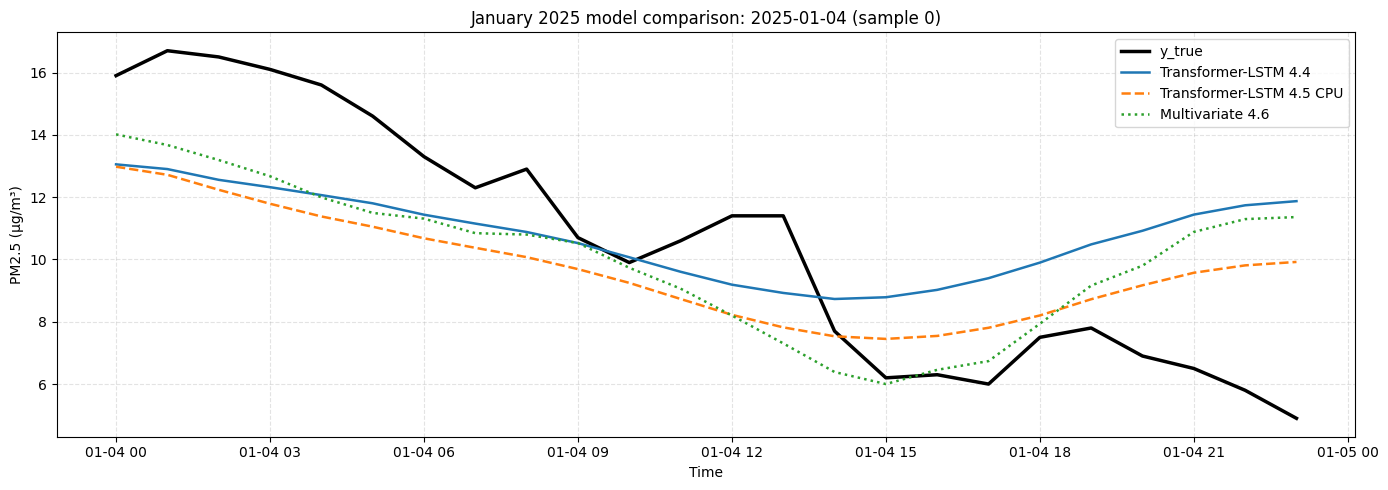

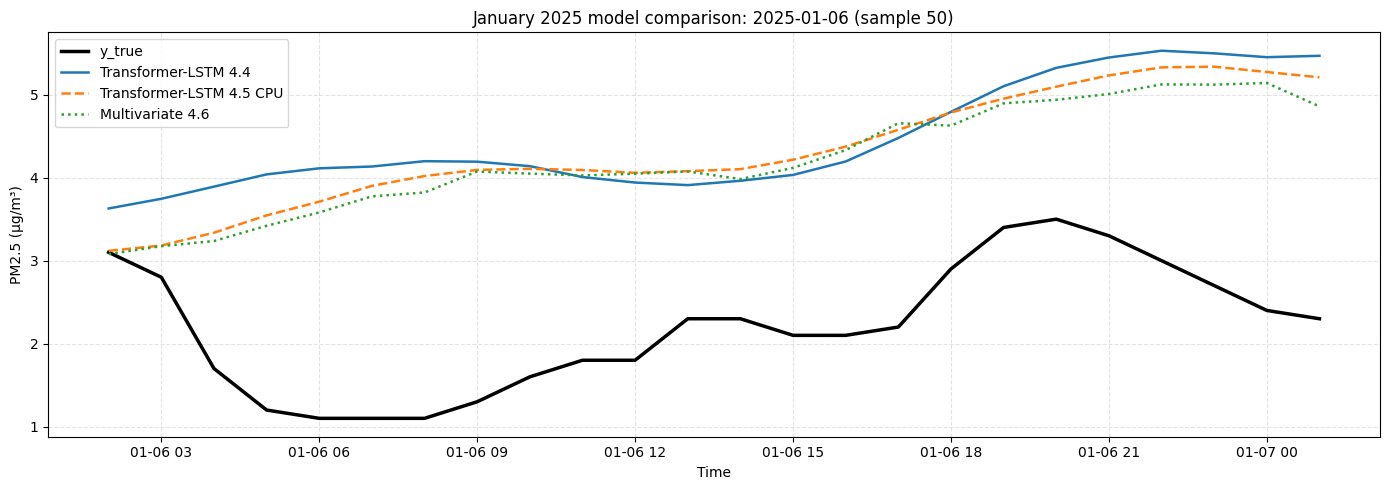

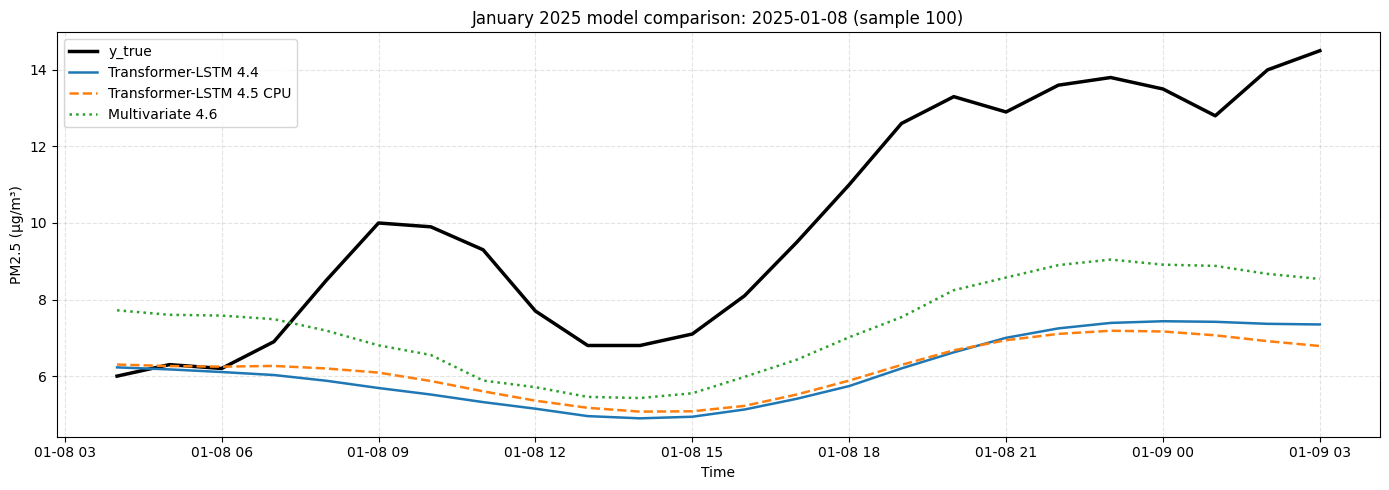

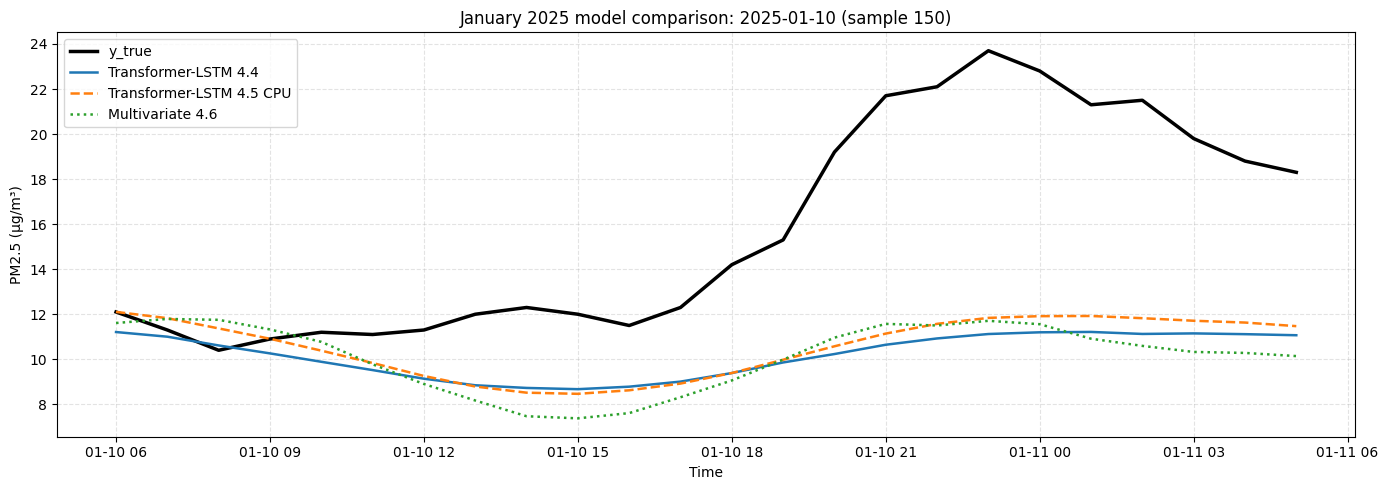

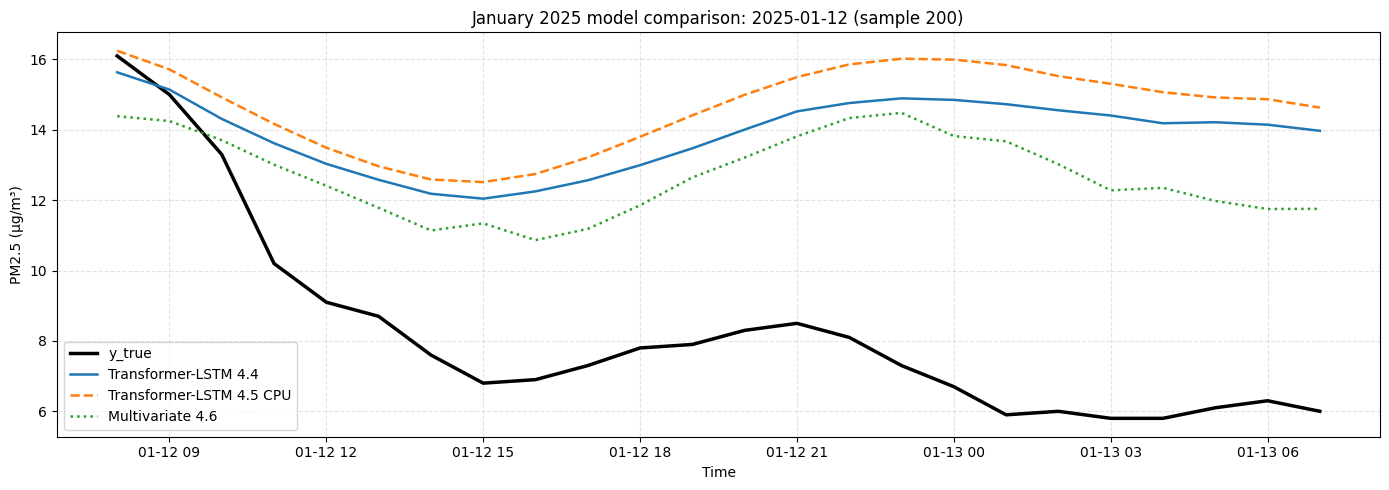

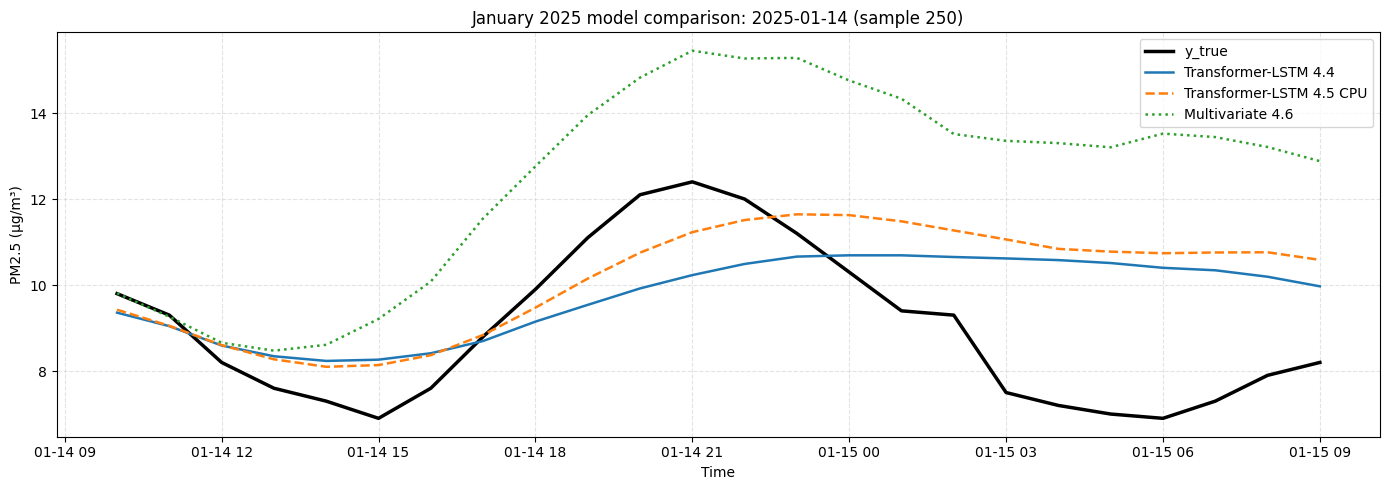

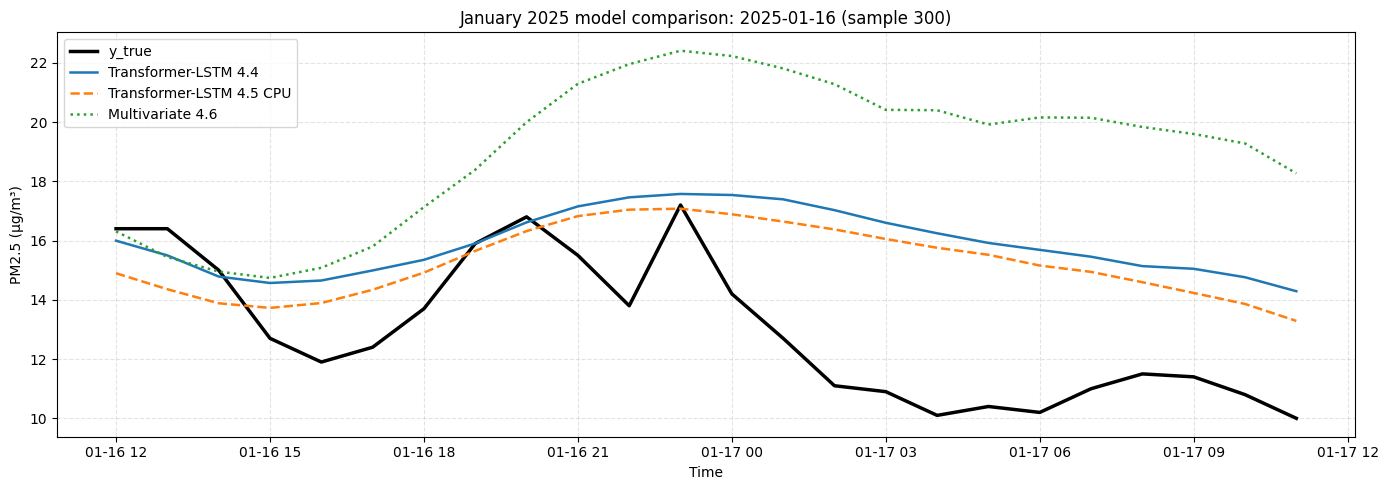

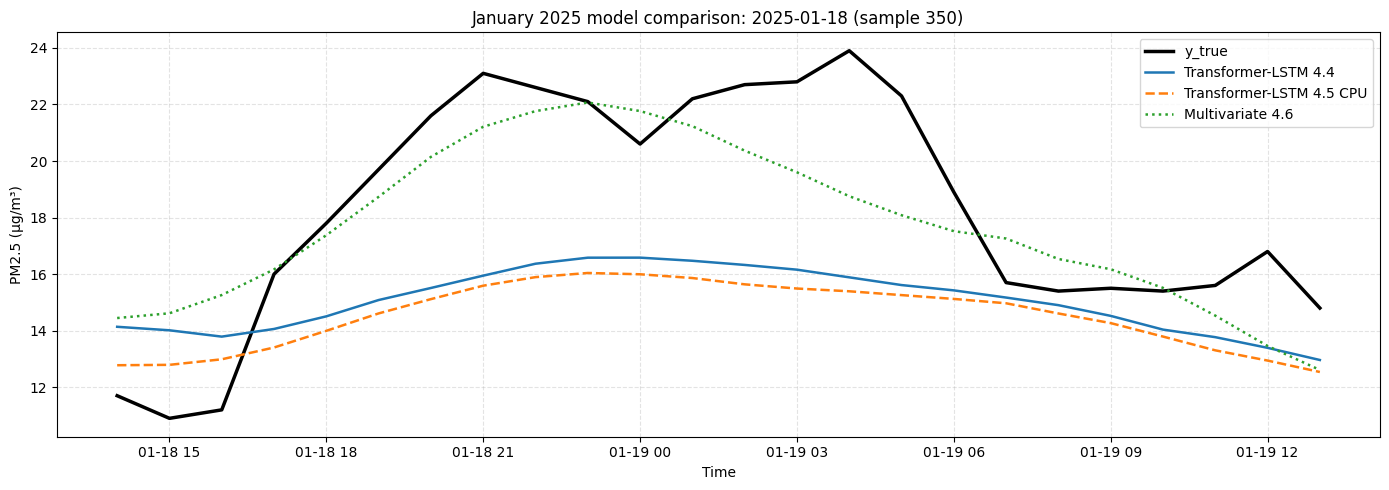

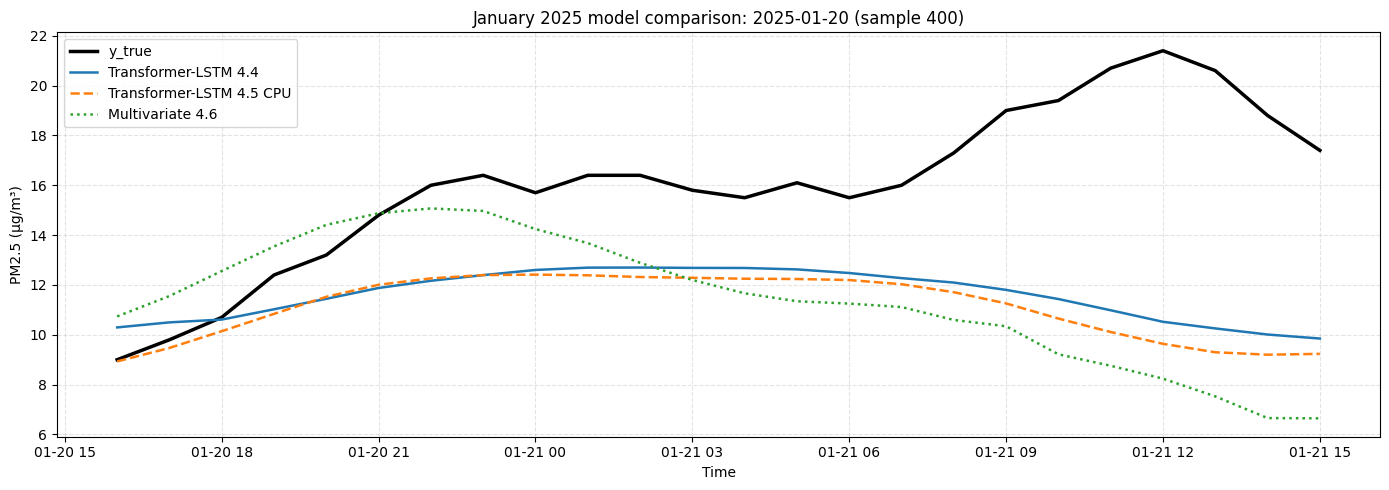

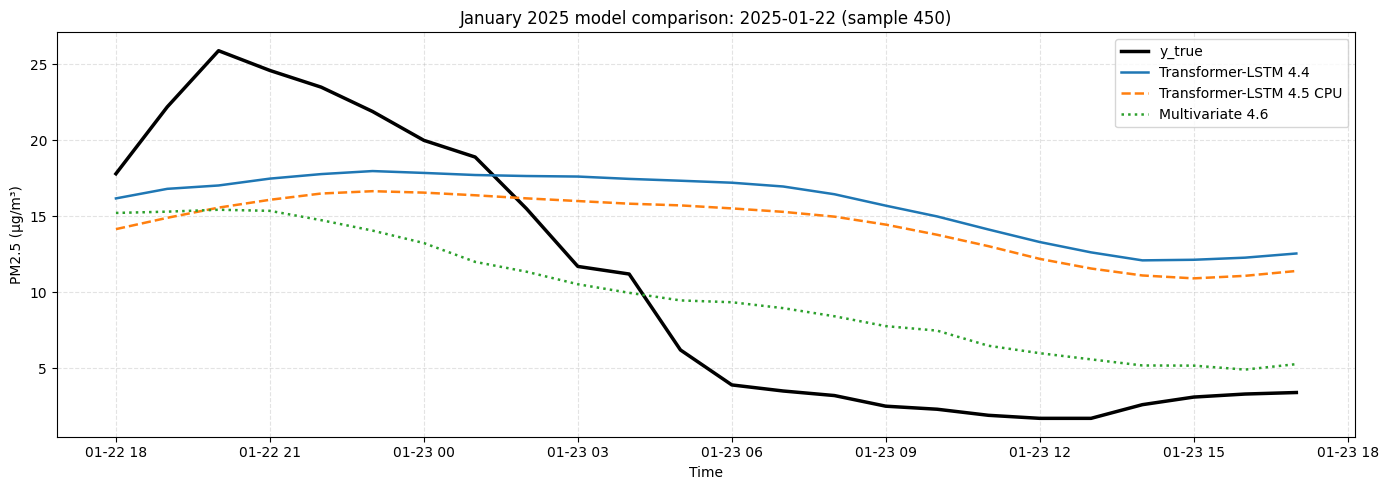

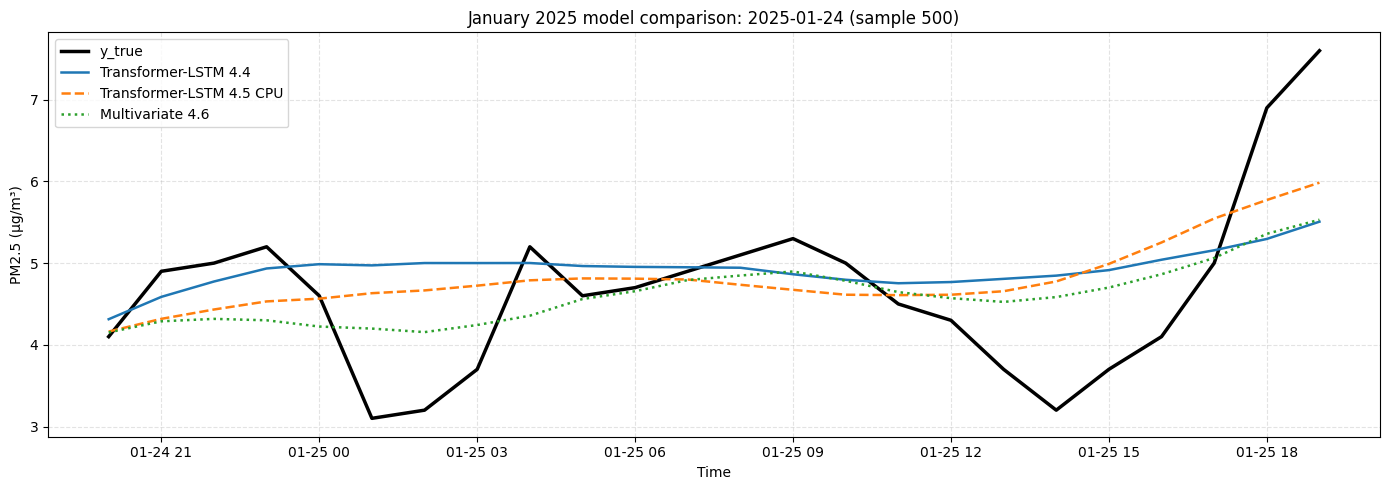

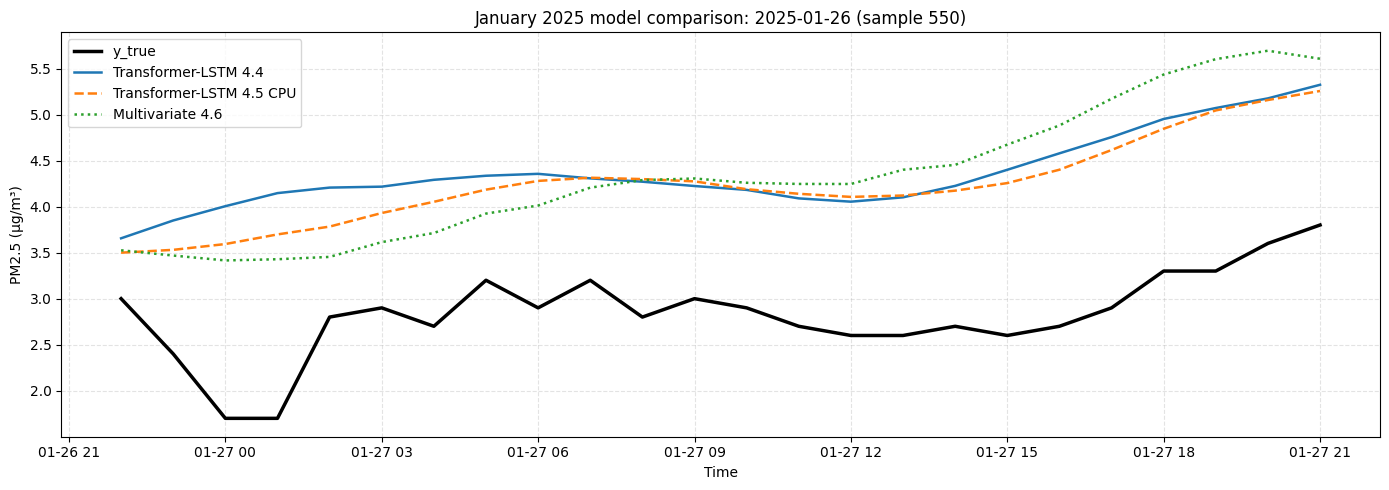

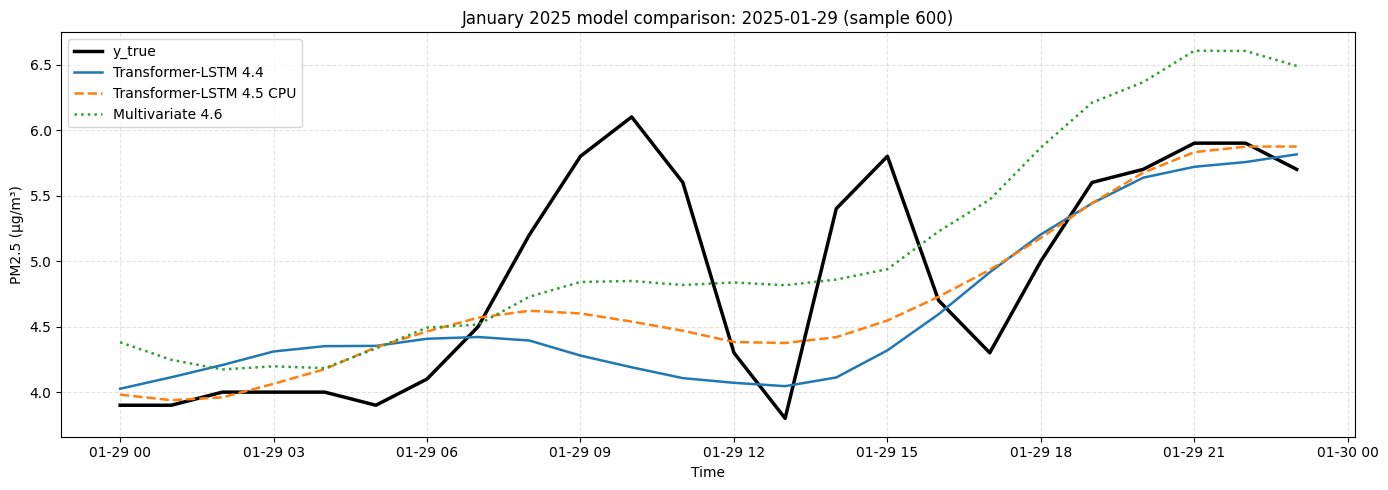

In [3]:
for sample_idx in sample_indices:
    timestamps = january_index[INPUT_WINDOW + sample_idx:INPUT_WINDOW + sample_idx + OUTPUT_WINDOW]
    if len(timestamps) != OUTPUT_WINDOW:
        continue
    date_str = timestamps[0].strftime("%Y-%m-%d")
    plt.figure(figsize=(14, 5))
    plt.plot(timestamps, true_values[sample_idx], label="y_true", color="black", linewidth=2.5)
    for model_name, model_predictions in predictions.items():
        linestyle = "--" if model_name.endswith("4.5 CPU") else ":" if model_name.endswith("4.6") else "-"
        plt.plot(timestamps, model_predictions[sample_idx], label=model_name, linewidth=1.8, linestyle=linestyle)
    plt.title(f"January 2025 model comparison: {date_str} (sample {sample_idx})")
    plt.xlabel("Time")
    plt.ylabel("PM2.5 (μg/m³)")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

January 2025 metrics (calculated after inverse transform):
                   model    MAE   RMSE     R2
        Multivariate 4.6 2.8600 3.9294 0.6265
    Transformer-LSTM 4.4 2.8770 4.0437 0.6045
Transformer-LSTM 4.5 CPU 2.7389 3.8580 0.6400


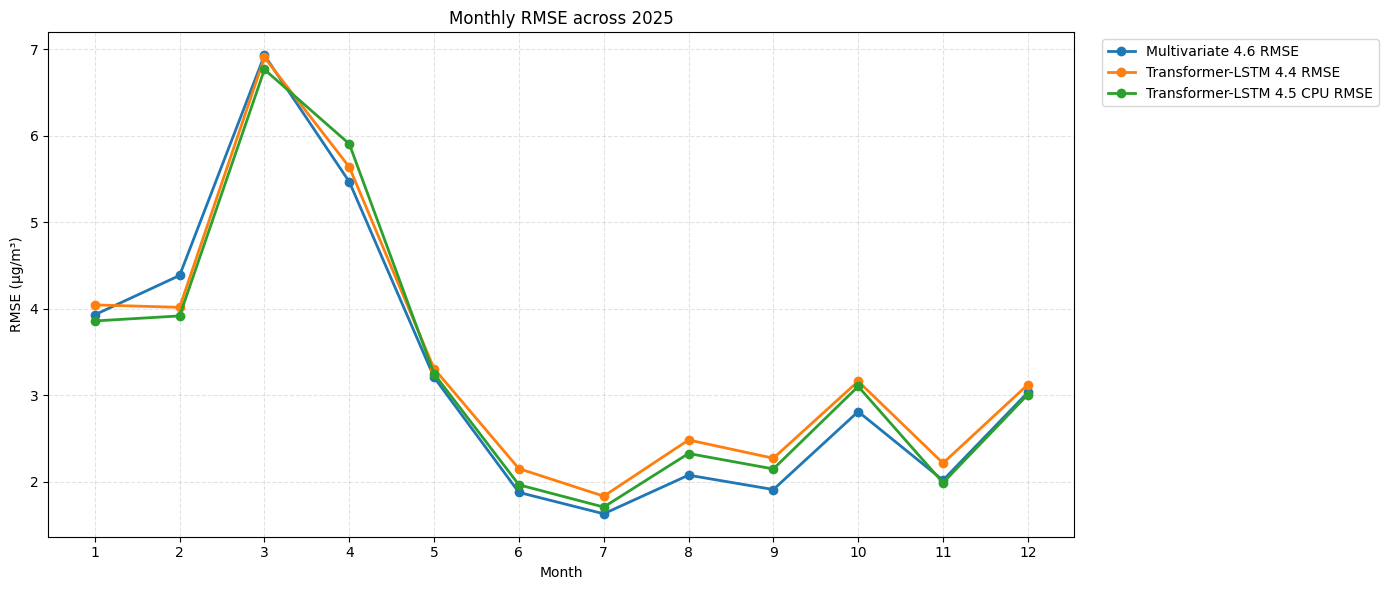

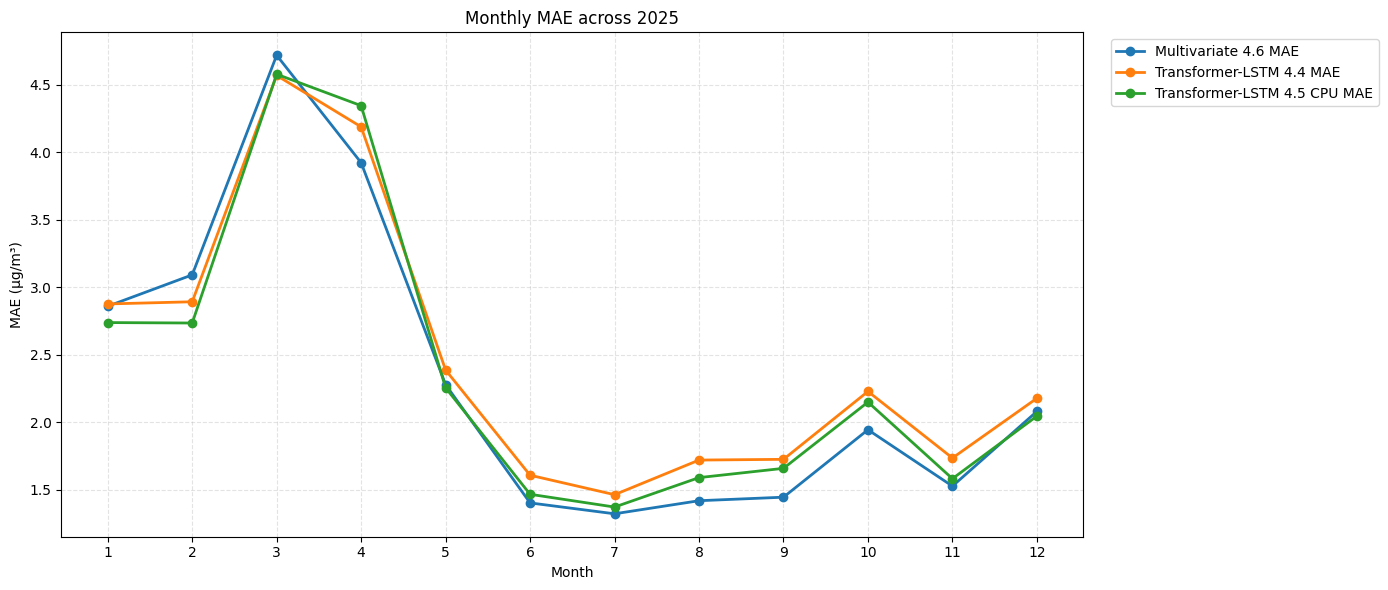

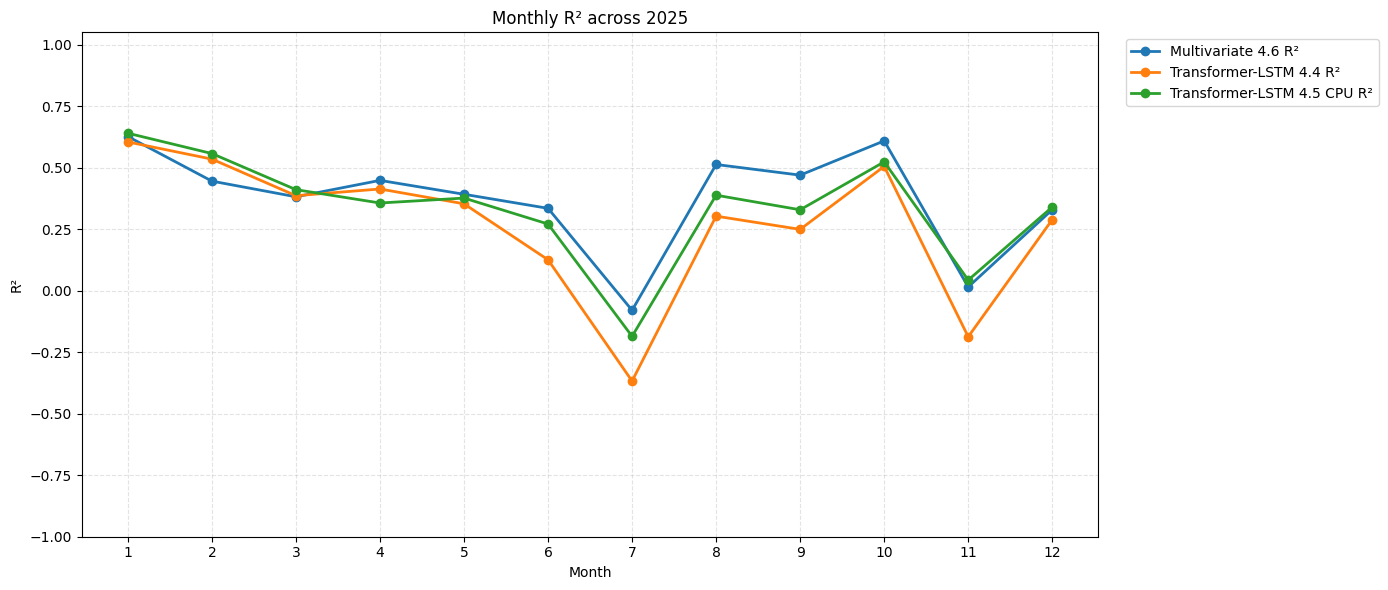

In [4]:
from sklearn.metrics import mean_absolute_error, r2_score


def inverse_target(values, scaler, target_idx=0):
    values = np.asarray(values, dtype=float)
    return (values - scaler.min_[target_idx]) / scaler.scale_[target_idx]


def build_annual_sequences(frame, feature_cols, year_start, year_end):
    start_ts = pd.Timestamp(year_start)
    end_ts = pd.Timestamp(year_end)
    train_raw = frame.loc[:start_ts - pd.Timedelta(hours=1), feature_cols].copy()
    eval_raw = frame.loc[start_ts:end_ts, feature_cols].copy()

    scaler = MinMaxScaler()
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_raw), columns=feature_cols, index=train_raw.index
    )
    eval_scaled = pd.DataFrame(
        scaler.transform(eval_raw), columns=feature_cols, index=eval_raw.index
    )
    X, y = make_sequences(eval_scaled, feature_cols)
    return X, y, eval_raw.index, scaler


X_2025_uni, y_2025_uni, year_index, uni_annual_scaler = build_annual_sequences(
    df_univariate,
    FEATURE_COLS,
    "2025-01-01 00:00:00",
    "2025-12-31 23:00:00",
)
X_2025_multi, y_2025_multi, _, multi_annual_scaler = build_annual_sequences(
    df_multivariate,
    MULTIVARIATE_COLS,
    "2025-01-01 00:00:00",
    "2025-12-31 23:00:00",
)

predictions_2025 = {
    "Transformer-LSTM 4.4": models["Transformer-LSTM 4.4"](
        torch.tensor(X_2025_uni, dtype=torch.float32, device=DEVICE)
    ).cpu().detach().numpy(),
    "Transformer-LSTM 4.5 CPU": models["Transformer-LSTM 4.5 CPU"](
        torch.tensor(X_2025_uni, dtype=torch.float32, device=DEVICE)
    ).cpu().detach().numpy(),
    "Multivariate 4.6": models["Multivariate 4.6"](
        torch.tensor(X_2025_multi, dtype=torch.float32, device=DEVICE)
    ).cpu().detach().numpy(),
}

true_2025 = inverse_target(y_2025_uni, uni_annual_scaler)

monthly_rows = []
for model_name, pred_scaled in predictions_2025.items():
    scaler = uni_annual_scaler if model_name != "Multivariate 4.6" else multi_annual_scaler
    pred = inverse_target(pred_scaled, scaler)
    flat_rows = []

    for seq_idx in range(len(pred)):
        forecast_ts = year_index[seq_idx + INPUT_WINDOW:seq_idx + INPUT_WINDOW + OUTPUT_WINDOW]
        for timestamp, y_true, y_hat in zip(forecast_ts, true_2025[seq_idx], pred[seq_idx]):
            flat_rows.append({
                "month": int(timestamp.month),
                "y_true": float(y_true),
                "y_pred": float(y_hat),
            })

    flat_df = pd.DataFrame(flat_rows)
    for month in range(1, 13):
        month_df = flat_df[flat_df["month"] == month]
        if month_df.empty:
            continue
        y_true = month_df["y_true"].to_numpy()
        y_pred = month_df["y_pred"].to_numpy()
        monthly_rows.append({
            "model": model_name,
            "month": month,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "R2": r2_score(y_true, y_pred),
        })

monthly_metrics = pd.DataFrame(monthly_rows).sort_values(["model", "month"]).reset_index(drop=True)

january_metrics = (
    monthly_metrics.loc[monthly_metrics["month"] == 1, ["model", "MAE", "RMSE", "R2"]]
    .sort_values("model")
    .reset_index(drop=True)
)
print("January 2025 metrics (calculated after inverse transform):")
print(january_metrics.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

plt.figure(figsize=(14, 6))
for model_name in sorted(monthly_metrics["model"].unique()):
    subset = monthly_metrics[monthly_metrics["model"] == model_name].sort_values("month")
    plt.plot(subset["month"], subset["RMSE"], marker="o", linewidth=2, label=f"{model_name} RMSE")
plt.title("Monthly RMSE across 2025")
plt.xlabel("Month")
plt.ylabel("RMSE (μg/m³)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for model_name in sorted(monthly_metrics["model"].unique()):
    subset = monthly_metrics[monthly_metrics["model"] == model_name].sort_values("month")
    plt.plot(subset["month"], subset["MAE"], marker="o", linewidth=2, label=f"{model_name} MAE")
plt.title("Monthly MAE across 2025")
plt.xlabel("Month")
plt.ylabel("MAE (μg/m³)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for model_name in sorted(monthly_metrics["model"].unique()):
    subset = monthly_metrics[monthly_metrics["model"] == model_name].sort_values("month")
    plt.plot(subset["month"], subset["R2"], marker="o", linewidth=2, label=f"{model_name} R²")
plt.title("Monthly R² across 2025")
plt.xlabel("Month")
plt.ylabel("R²")
plt.xticks(range(1, 13))
plt.ylim(min(-1.0, monthly_metrics["R2"].min() - 0.1), 1.05)
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


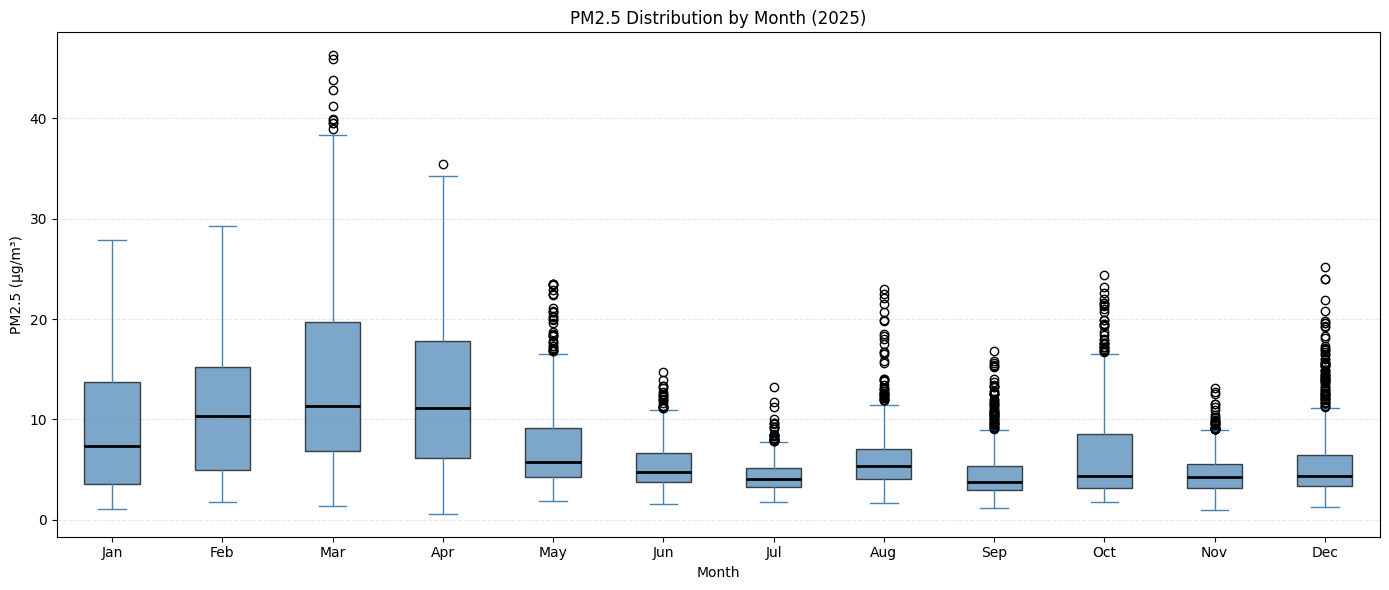

In [5]:
monthly_distribution = df_univariate.loc["2025-01-01":"2025-12-31", TARGET_COL].copy().to_frame("pm2_5")
monthly_distribution["month"] = monthly_distribution.index.month
monthly_distribution["month_name"] = monthly_distribution.index.strftime("%b")

month_labels = [pd.Timestamp(2025, m, 1).strftime("%b") for m in range(1, 13)]
month_values = [
    monthly_distribution.loc[monthly_distribution["month"] == m, "pm2_5"].values
    for m in range(1, 13)
]

plt.figure(figsize=(14, 6))
plt.boxplot(
    month_values,
    tick_labels=month_labels,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue")
)
plt.title("PM2.5 Distribution by Month (2025)")
plt.xlabel("Month")
plt.ylabel("PM2.5 (μg/m³)")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
